Si consideri il dataset clinico SUPPORT2, contenente informazioni demografiche, fisiologiche e di laboratorio
relative a pazienti ospedalizzati.

In [1]:
import pandas as pd
ds = pd.read_csv(".\dataset_esercitazione.csv", sep=',')
print(ds)

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\giova\AppData\Local\Temp\ipykernel_23376\674523165.py:2: SyntaxWarning: invalid escape sequence '\d'
  ds = pd.read_csv(".\dataset_esercitazione.csv", sep=',')


           age     sex            dzgroup             dzclass  num.co   edu  \
0     62.84998    male        Lung Cancer              Cancer       0  11.0   
1     60.33899  female          Cirrhosis  COPD/CHF/Cirrhosis       2  12.0   
2     52.74698  female          Cirrhosis  COPD/CHF/Cirrhosis       2  12.0   
3     42.38498  female        Lung Cancer              Cancer       2  11.0   
4     79.88495  female  ARF/MOSF w/Sepsis            ARF/MOSF       1   NaN   
...        ...     ...                ...                 ...     ...   ...   
9100  66.07300    male  ARF/MOSF w/Sepsis            ARF/MOSF       1   8.0   
9101  55.15399  female               Coma                Coma       1  11.0   
9102  70.38196    male  ARF/MOSF w/Sepsis            ARF/MOSF       1   NaN   
9103  47.01999    male       MOSF w/Malig            ARF/MOSF       1  13.0   
9104  81.53894  female  ARF/MOSF w/Sepsis            ARF/MOSF       1   8.0   

          income  scoma  charges      totcst  ...  

Dopo aver caricato i dati, rimuovere le variabili di outcome e prognosi per
evitare fenomeni di data leakage e selezionare una variabile target (ad esempio dzgroup).

In [44]:
#variabili di outcome: death, dts, surv2m, surv6m, hospdead
#variabili di prognosi: sps, aps, surv, prg2m, prg6m
#variabile target: dzgroup

X = ds.drop(columns=['death', 'dzgroup', 'hday', 'dnrday', 'surv2m', 'surv6m', 'sps', 'aps', 'prg2m', 'prg6m', 'dnr', 'charges', 'totcst', 'totmcst', 'avtisst'])
y = ds['death']

Suddividere il dataset in training set (95%) e test set (5%) utilizzando un campionamento stratificato rispetto
alla variabile target («death»), in modo da preservare la distribuzione delle classi.

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, stratify=y)

Gestire i dati mancanti applicando imputazione con mediana per le variabili numeriche e con un valore
costante (ad esempio "Unknown") per quelle categoriche; successivamente codificare le variabili categoriche
tramite Ordinal Encoding.

In [46]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer

cat_values = X_train.select_dtypes(include=['object', 'bool']).columns.tolist()
num_values = X_train.select_dtypes(include=['number']).columns.tolist()

#per gestire i dati mancanti
report_missing = X_train.isnull().sum() / len(X_train) * 100
print(report_missing)

#contiamo le colonne con i dati mancanti
nan_columns = report_missing[report_missing > 0].index.tolist()
missing_cat = [col for col in nan_columns if col in cat_values]
missing_num = [col for col in nan_columns if col in num_values]

#impostiamo l'imputazione per variabili numeriche e categoriche
if len(missing_num) > 0:
    imputer_num = SimpleImputer(strategy='median')
    X_train[missing_num] = imputer_num.fit_transform(X_train[missing_num])
    X_test[missing_num] = imputer_num.transform(X_test[missing_num])
if len(missing_cat) > 0:
    imputer_cat = SimpleImputer(strategy='constant', fill_value='Unknown')
    X_train[missing_cat] = imputer_cat.fit_transform(X_train[missing_cat])
    X_test[missing_cat] = imputer_cat.transform(X_test[missing_cat])

#encoding per variabili categoriche
#eventuale controllo di esistenza
encoder_cat = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-5)
X_train[cat_values] = encoder_cat.fit_transform(X_train[cat_values])
X_test[cat_values] = encoder_cat.transform(X_test[cat_values])

age          0.000000
sex          0.000000
dzclass      0.000000
num.co       0.000000
edu         17.909585
income      32.662736
scoma        0.011562
race         0.462481
diabetes     0.000000
dementia     0.000000
ca           0.000000
meanbp       0.011562
wblc         2.277720
hrt          0.011562
resp         0.011562
temp         0.011562
pafi        25.586773
alb         37.021621
bili        28.569777
crea         0.705284
sod          0.011562
ph          25.135854
glucose     49.497052
bun         47.855243
urine       53.497514
adlp        61.949358
adls        31.414036
adlsc        0.000000
dtype: float64


Applicare lo scaling delle feature numeriche tramite z-scoring, quindi calcolare e analizzare la matrice di
correlazione, individuando eventuali coppie di variabili altamente correlate e discutendo la presenza di
multicollinearità.

               age       sex   dzclass    num.co       edu    income  \
age       1.000000 -0.042713  0.078902  0.127011 -0.118781  0.066316   
sex      -0.042713  1.000000  0.006750  0.048124 -0.004306 -0.090137   
dzclass   0.078902  0.006750  1.000000  0.004748  0.008394 -0.026372   
num.co    0.127011  0.048124  0.004748  1.000000 -0.098093  0.088933   
edu      -0.118781 -0.004306  0.008394 -0.098093  1.000000 -0.204648   
income    0.066316 -0.090137 -0.026372  0.088933 -0.204648  1.000000   
scoma     0.005295 -0.041797  0.191704 -0.124643  0.004362  0.021299   
race      0.165639  0.046097  0.014918  0.007943  0.092588 -0.126168   
diabetes  0.094555 -0.043472 -0.067837  0.384203 -0.063516  0.036625   
dementia  0.197220 -0.030433 -0.019380  0.137527 -0.011444  0.053866   
ca        0.043600  0.001885 -0.387046  0.162890 -0.047573  0.061983   
meanbp   -0.039724 -0.007440  0.080773 -0.014323 -0.033116 -0.005388   
wblc      0.007388 -0.018924 -0.027233 -0.008765 -0.006116  0.01

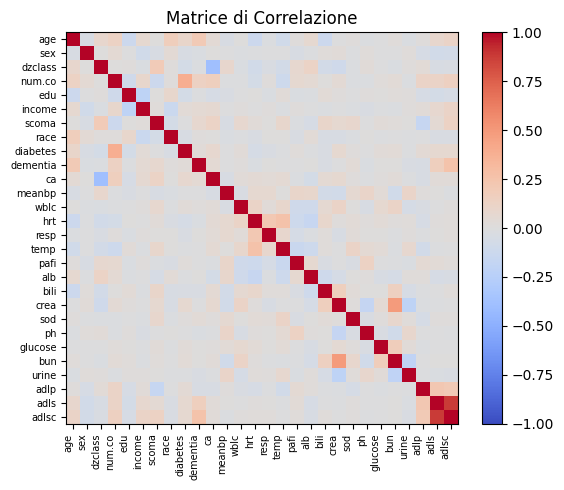

Rilevate coppie con correlazione superiore a 0.8
Correlazione di 0.8801580903286088 per la coppia [adlsc, adls]


In [47]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plot
import numpy as np

scaler = StandardScaler()
#applichiamo lo scaling delle feature numeriche tramite z-scoring
X_train[num_values] = scaler.fit_transform(X_train[num_values])
X_test[num_values] = scaler.transform(X_test[num_values])

#calcoliamo la matrice di correlazione su X_train (feature numriche + feature categoriche dopo l'encoding)
corr_matrix = X_train.corr()
print(corr_matrix)
#analisi matrice
corr_figure, graph_area = plot.subplots(figsize=(7, 5))  #figura e area di disegno
color_map = graph_area.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)  #mappa di calore
corr_figure.colorbar(color_map, fraction=0.04, pad=0.04)  #scala colore

var_num = np.arange(len(corr_matrix.columns))  #etichette sugli assi
var_names = corr_matrix.columns

graph_area.set_xticks(var_num)
graph_area.set_xticklabels(var_names, rotation=90, ha='right', fontsize=7)  #nomi alle tacche degli assi
graph_area.set_yticks(var_num)
graph_area.set_yticklabels(var_names, fontsize=7)

plot.title("Matrice di Correlazione")
plot.tight_layout()
plot.show()  #stampa grafico matrice

#analisi multicollinearità
rel_threshold = 0.8
corr_pairs = corr_matrix.unstack().sort_values(key=abs)
corr_pairs = corr_pairs[corr_pairs != 1.0]  #eliminiamo l'autocorrelazione
related_pairs = corr_pairs[abs(corr_pairs) > rel_threshold]  #le coppie altamente correlate avranno correlazione maggiore della soglia

var_to_remove = set()  #impostiamo un set per non avere duplicati
if not related_pairs.empty:
    print(f'Rilevate coppie con correlazione superiore a {rel_threshold}')
    for i, value in related_pairs[::2].items():
        var1, var2 = i
        print(f'Correlazione di {value} per la coppia [{var1}, {var2}]')
        var_to_remove.add(var2)  #scegliamo arbitrariamente di rimuovere la seconda variabile
else:
    print('Nessuna correlazione critica rilevata')